# Customer Churn Analysis – Python EDA

## Objective
Analyze customer churn patterns, identify key factors associated with churn,
and quantify revenue at risk using Python.

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

In [6]:
df = pd.read_csv("telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup,AverageMonthlyRevenue
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,Low,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Established,Medium,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,Medium,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Established,Medium,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,Medium,75.825000


## 3. Dataset Overview

In [7]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 24)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'MonthlyChargeGroup', 'AverageMonthlyRevenue']

Data types:
customerID                object
gender                    object
SeniorCitizen             object
Partner                   object
Dependents                object
tenure                     int64
PhoneService              object
MultipleLines             object
InternetService           object
OnlineSecurity            object
OnlineBackup              object
DeviceProtection          object
TechSupport               object
StreamingTV               object
StreamingMovies           object
Contract                  object
PaperlessBilling          object
Payment

## 4. Dataset Quality Check

In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
customerID               0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn                    0
TenureGroup              0
MonthlyChargeGroup       0
AverageMonthlyRevenue    0
dtype: int64

Duplicate rows: 0


## 5. Overall Churn Analysis

In [9]:
churn_count = df["Churn"].value_counts()

print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [10]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


### Churned vs Retained Customers Graph

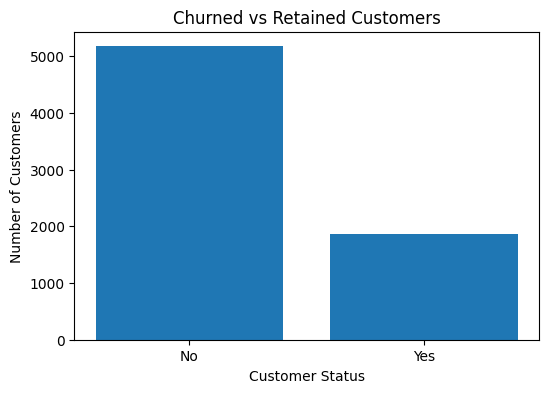

In [11]:
churn_count = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_count.index, churn_count.values)

plt.title("Churned vs Retained Customers")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

## 6. Churn by Tenure Group

In [14]:
tenure_order = ["New", "Early", "Established", "Loyal"]

tenure_churn = pd.crosstab(
    pd.Categorical(
        df["TenureGroup"],
        categories=tenure_order,
        ordered=True
    ),
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
row_0,,
New,52.561757,47.438243
Early,71.289062,28.710938
Established,79.611041,20.388959
Loyal,90.486824,9.513176


### Churn by Tenure Group Graph

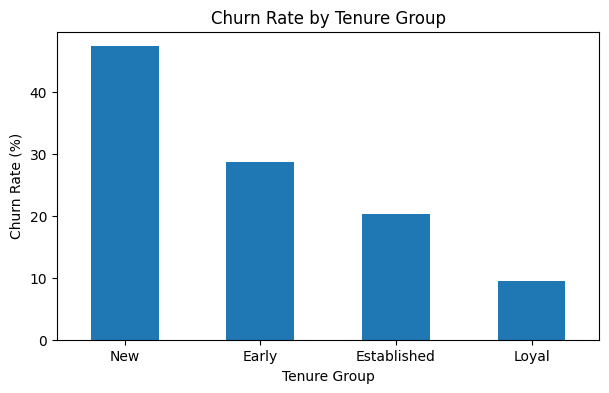

In [15]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 7. Churn by Contract Type

In [17]:
contract_order = ["Month-to-month", "One year", "Two year"]

contract_churn = pd.crosstab(
    pd.Categorical(
        df["Contract"],
        categories=contract_order,
        ordered=True
    ),
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
row_0,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Churn by Contract Type Graph

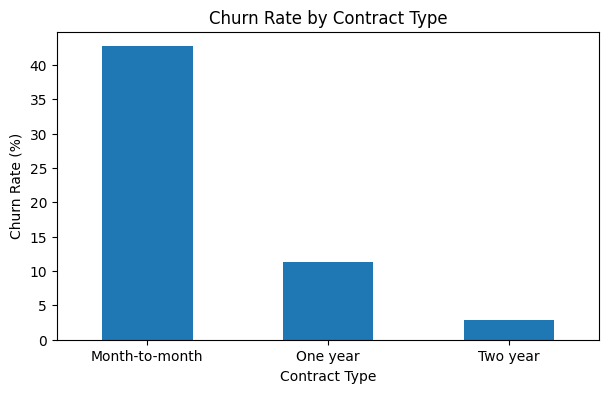

In [18]:
contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 8. Churn by Payment Method

In [19]:
payment_order = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

payment_churn = pd.crosstab(
    pd.Categorical(
        df["PaymentMethod"],
        categories=payment_order,
        ordered=True
    ),
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
row_0,,
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101


### Churn by Payment Method Graph

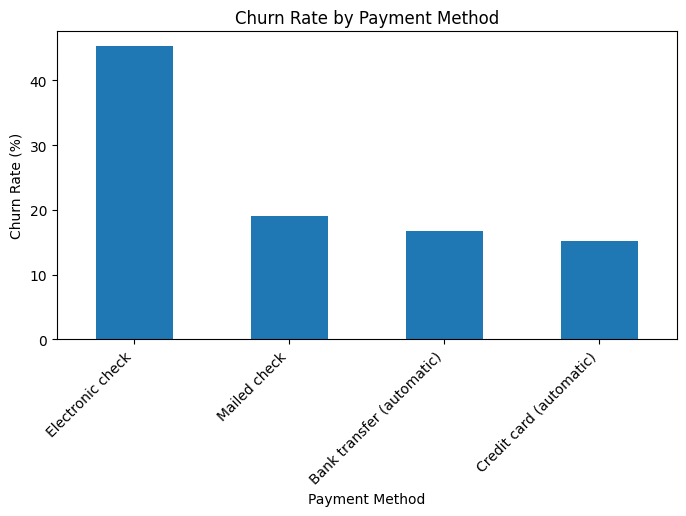

In [26]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

## 9. Churn by Internet Service

In [27]:
internet_order = [
    "DSL",
    "Fiber optic",
    "No"
]

internet_churn = pd.crosstab(
    pd.Categorical(
        df["InternetService"],
        categories=internet_order,
        ordered=True
    ),
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
row_0,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Churn by Internet Service Graph

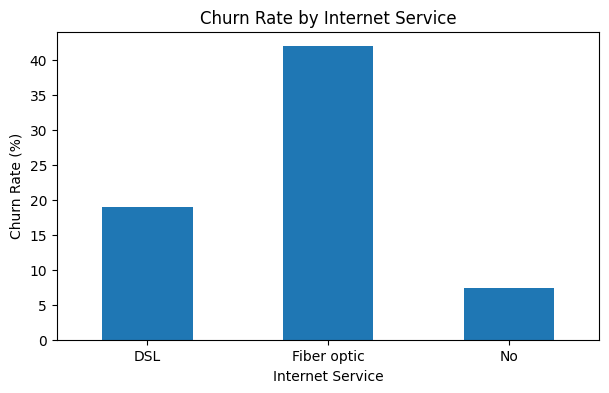

In [30]:
internet_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 10. Monthly Charges vs Churn

In [32]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Monthly Charges vs Churn Graph

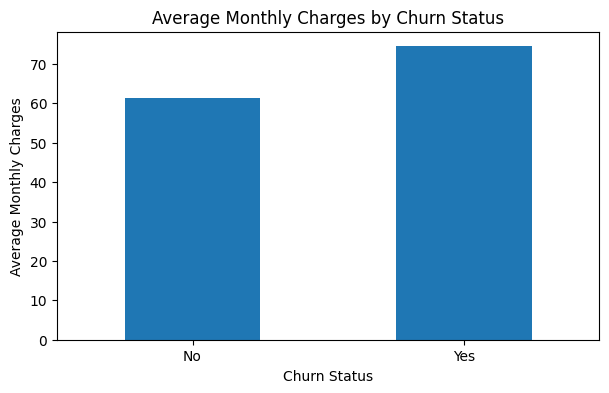

In [33]:
monthly_charges_churn.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)

plt.show()

## 11. Tenure vs churn

In [34]:
tenure_churn = df.groupby("Churn")["tenure"].mean()

tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Tenure vs Churn Graph

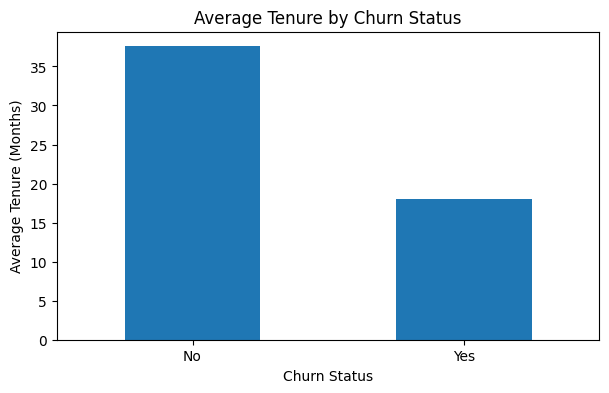

In [35]:
tenure_churn.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Average Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

plt.show()

## 12. Revenue at Risk

In [36]:
revenue_at_risk = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

print(f"Monthly revenue at risk: ${revenue_at_risk:,.2f}")

Monthly revenue at risk: $139,130.85


In [37]:
total_monthly_revenue = df["MonthlyCharges"].sum()

print(f"Total monthly revenue: ${total_monthly_revenue:,.2f}")

Total monthly revenue: $456,116.60


In [38]:
revenue_risk_percentage = (
    revenue_at_risk / total_monthly_revenue
) * 100

print(f"Revenue at risk: {revenue_risk_percentage:.2f}%")

Revenue at risk: 30.50%


## 13. Key Insights

1. Overall Churn: The overall churn rate is 26.54%, with 1,869 out of 7,043 customers having churned.
2. Tenure: New customers have the highest churn rate at 47.44%, while Loyal customers have the lowest at 9.51%. Churn generally decreases as customer tenure increases.
3. Contract Type: Month-to-month customers have a churn rate of 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.
4. Payment Method: Customers using Electronic check have the highest churn rate at 45.29%, substantially higher than customers using automatic payment methods.
5. Internet Service: Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.
6. Monthly Charges: Churned customers have higher average monthly charges than retained customers,indicating an association between higher charges and churn.
7. Customer Tenure: Churned customers have an average tenure of 17.98 months, compared with 37.57 months for retained customers.
8. Revenue at Risk: Churned customers account for approximately $139,130.85 in monthly charges, representing 30.50% of the total monthly charges in the dataset.

## 14. Business Recommendations

Based on the analysis, some actions that could help reduce customer churn are:

1. Focus more on new customers: Improve the onboarding process and provide better support during the first few months, as new customers have the highest churn rate.
2. Encourage longer contracts: Offer discounts or other benefits to month-to-month customers to encourage them to choose one-year or two-year contracts.
3. Promote automatic payments: Encourage customers using Electronic check to switch to automatic payment methods by making the process easier and offering suitable incentives.
4. Look into Fiber optic customers: Since Fiber optic customers have a higher churn rate, the company should check factors such as service quality, pricing, and technical support for this group.
5. Review higher monthly charges: Churned customers have higher average monthly charges, so the company should check whether these customers feel they are getting enough value from the services they are paying for.
6. Focus on customers with higher revenue at risk: Customers who have higher monthly charges and are at risk of churning should be given more attention through targeted retention offers and support.